# Music Taste Evolution (2008–2025)

Note: All analyses are based on unique artist–track combinations after cleaning and normalization rather than raw scrobble counts. The objective is to analyse repertoire evolution and music discovery patterns, not listening frequency.

## Load libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import entropy
import numpy as np

## Load data

In [ ]:
analysis_df = pd.read_csv(
    "../data/processed/final/music_taste_analysis_ready.csv"
)

In [ ]:
analysis_df.columns

In [19]:
analysis_df.shape

(70217, 16)

In [ ]:
# Exclude incomplete years

analysis_df = analysis_df[
    (analysis_df["year_file"] >= 2008)
    & (analysis_df["year_file"] <= 2025)
]

In [20]:
analysis_df.shape

(70217, 16)

In [ ]:
macro_year = (
    analysis_df
    .groupby(["year_file", "macro_cluster"])
    .size()
    .unstack(fill_value=0)
)

macro_pct = (
    pd.crosstab(
        analysis_df["year_file"],
        analysis_df["macro_cluster"],
        normalize="index"
    )
)

macro_pct.head()

The figures below are exported for use in the project README.

## 1. Evolution of musical preferences

<Figure size 1200x600 with 0 Axes>

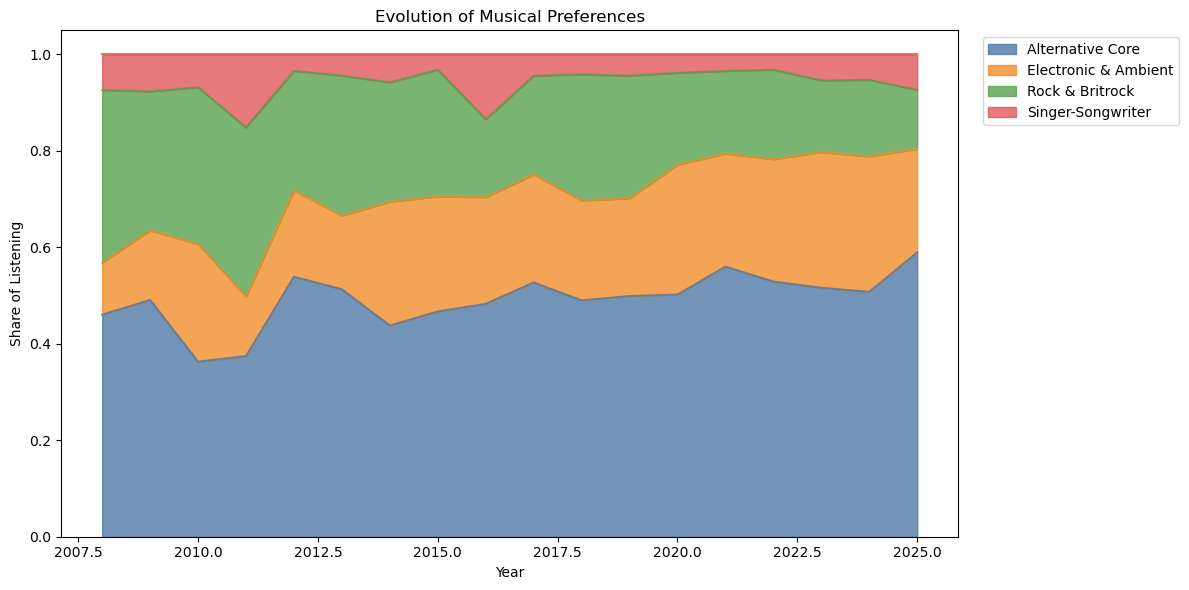

In [21]:
CLUSTER_COLORS = {
    "Alternative Core": "#4E79A7",      
    "Electronic & Ambient": "#F28E2B",            
    "Rock & Britrock": "#59A14F",                  
    "Singer-Songwriter": "#E15759"             
}

colors = [CLUSTER_COLORS[c] for c in macro_pct.columns]

plt.figure(figsize=(12,6))

macro_pct.plot.area(
    figsize=(12,6),
    alpha=0.8,
    color=colors
)

plt.title("Evolution of Musical Preferences")
plt.ylabel("Share of Listening")
plt.xlabel("Year")

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

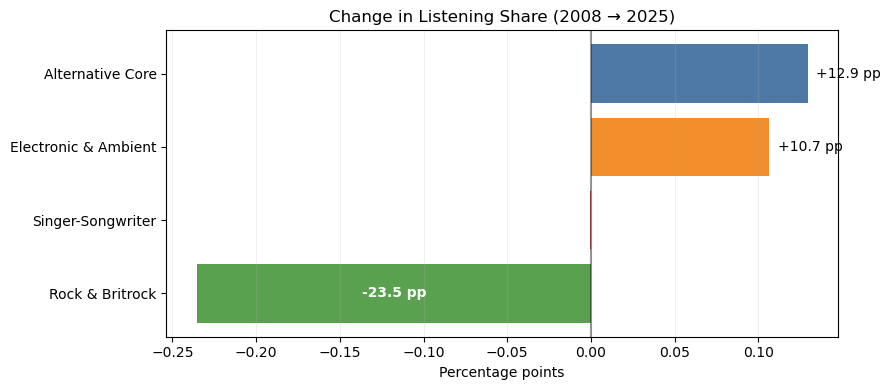

In [22]:
# Change in listening share over time

change = macro_pct.loc[2025] - macro_pct.loc[2008]
change = change.sort_values()

colors = [CLUSTER_COLORS[c] for c in change.index]

plt.figure(figsize=(9, 4))

bars = plt.barh(
    change.index,
    change.values,
    color=colors
)

plt.axvline(0, color="black", alpha=0.4)

# Add labels
for bar in bars:
    width = bar.get_width()
    
    if abs(width) < 0.005:
        continue

    if width > 0:
        plt.text(
            width + 0.005,
            bar.get_y() + bar.get_height()/2,
            f"{width*100:+.1f} pp",
            va="center",
            ha="left"
        )
    else:
        plt.text(
            width / 2,
            bar.get_y() + bar.get_height()/2,
            f"{width*100:+.1f} pp",
            va="center",
            ha="center",
            color="white",
            fontweight="bold"
        )

plt.title("Change in Listening Share (2008 → 2025)")
plt.xlabel("Percentage points")
plt.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.show()

## 2. New artists discovered per year (music discovery)

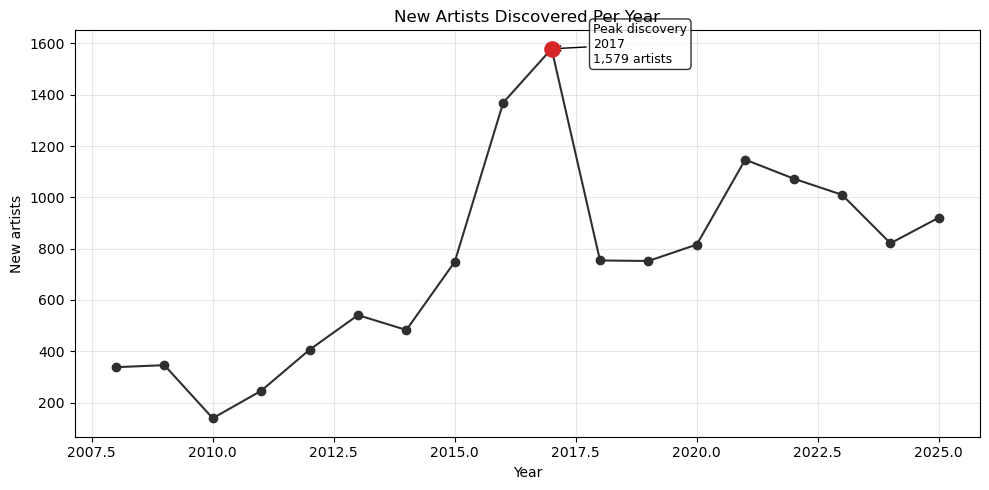

In [23]:
# How many new artists I discovered per year?

METRIC_COLOR = "#2F2F2F"
HIGHLIGHT_COLOR = "#D62728"

first_seen = (
    analysis_df
    .groupby("artist_clean")["year_file"]
    .min()
)

new_artists_per_year = (
    first_seen
    .value_counts()
    .sort_index()
)

peak_year = new_artists_per_year.idxmax()
peak_value = new_artists_per_year.max()

plt.figure(figsize=(10,5))

plt.plot(
    new_artists_per_year.index,
    new_artists_per_year.values,
    marker="o",
    color=METRIC_COLOR
)

# Peak marker
plt.scatter(
    peak_year,
    peak_value,
    color=HIGHLIGHT_COLOR,
    s=120,
    zorder=5,
    label="Peak discovery"
)

plt.annotate(
    f"Peak discovery\n{peak_year}\n{peak_value:,} artists",
    xy=(peak_year, peak_value),
    xytext=(30, -10),
    textcoords="offset points",
    bbox=dict(
        boxstyle="round,pad=0.3",
        fc="white",
        alpha=0.8
    ),
    arrowprops=dict(arrowstyle="->"),
    fontsize=9
)

plt.title("New Artists Discovered Per Year")
plt.xlabel("Year")
plt.ylabel("New artists")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Music Taste Diversity Over Time

In [ ]:
macro_counts = (
    analysis_df
    .groupby(["year_file", "macro_cluster"])
    .size()
    .unstack(fill_value=0)
)

macro_entropy = macro_counts.apply(entropy, axis=1)

max_entropy = np.log(len(macro_counts.columns))
macro_entropy_norm = macro_entropy / max_entropy

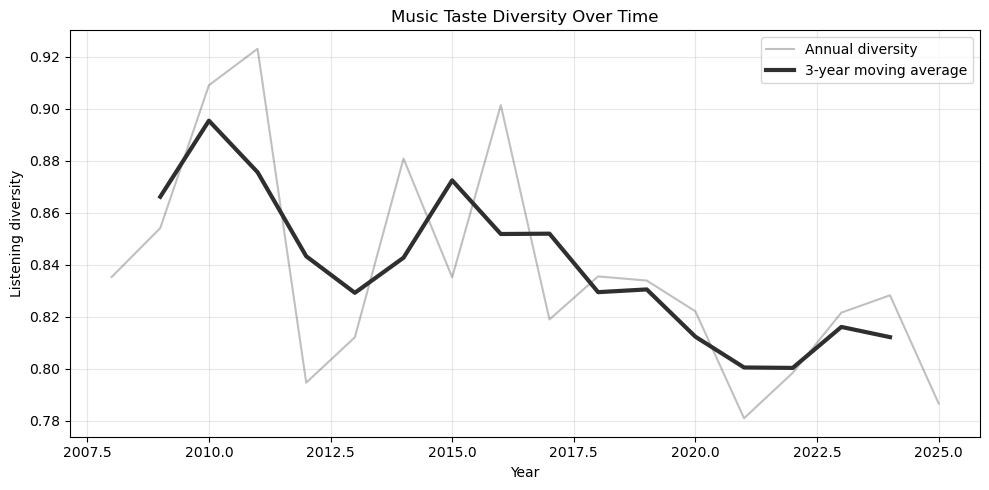

In [24]:
METRIC_COLOR = "#2F2F2F"
macro_entropy_smooth = macro_entropy_norm.rolling(3, center=True).mean()

plt.figure(figsize=(10, 5))

plt.plot(macro_entropy_norm.index, macro_entropy_norm.values, alpha=0.3, label="Annual diversity", color=METRIC_COLOR)
plt.plot(macro_entropy_norm.index, macro_entropy_smooth, linewidth=3, label="3-year moving average", color=METRIC_COLOR)

plt.legend()
plt.title("Music Taste Diversity Over Time")
plt.xlabel("Year")
plt.ylabel("Listening diversity")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 4. Artist concentration over time

/var/folders/gp/nj314n8s4h90zghjg44d68xr0000gn/T/ipykernel_1064/621921253.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(top20_share)


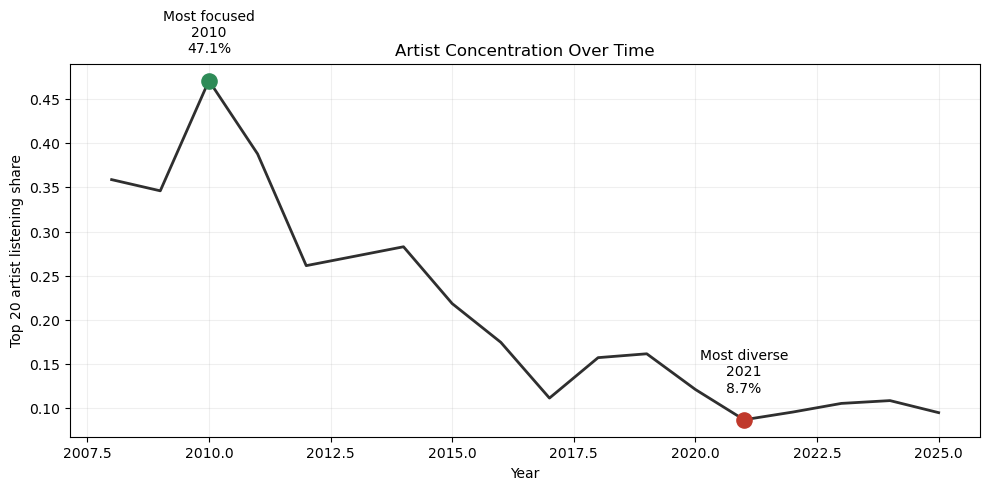

In [25]:
# How many artists came back? Top 20 artists each year? What's the concentration of listening in top 20 artists each year?
METRIC_COLOR = "#2F2F2F"

def top20_share(group):
    counts = group["artist_clean"].value_counts()
    return counts.head(20).sum() / counts.sum()

artist_concentration = (
    analysis_df
    .groupby("year_file")
    .apply(top20_share)
)

max_year = artist_concentration.idxmax()
max_val = artist_concentration.max()

min_year = artist_concentration.idxmin()
min_val = artist_concentration.min()

plt.figure(figsize=(10,5))

plt.plot(
    artist_concentration.index,
    artist_concentration.values,
    color="#2F2F2F",
    linewidth=2
)

# max
plt.scatter(max_year, max_val, color="#2E8B57", s=120, zorder=5)

plt.annotate(
    f"Most focused\n{max_year}\n{max_val:.1%}",
    (max_year, max_val),
    xytext=(0, 20),
    textcoords="offset points",
    ha="center"
)

# min
plt.scatter(min_year, min_val, color="#C0392B", s=120, zorder=5)

plt.annotate(
    f"Most diverse\n{min_year}\n{min_val:.1%}",
    (min_year, min_val),
    xytext=(0, 20),
    textcoords="offset points",
    ha="center"
)

plt.title("Artist Concentration Over Time")
plt.xlabel("Year")
plt.ylabel("Top 20 artist listening share")

plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## 5. Top artists by era

In [ ]:
# Top artist by Era

def assign_era(year):
    if year <= 2011:
        return "2008-2011"
    elif year <= 2016:
        return "2012-2016"
    elif year <= 2021:
        return "2017-2021"
    else:
        return "2022-2025"

analysis_df["era"] = analysis_df["year_file"].apply(assign_era)

In [ ]:
# Top 10 artists per era
top_artists_by_era = (
   analysis_df
    .groupby("era")["artist_clean"]
    .value_counts()
    .groupby(level=0)
    .head(10)
)

top_artists_by_era

## 6. Artist retention over time

In [ ]:
# How often do artists remain part of the yearly repertoire from one year to the next?

artists_by_year = (analysis_df.groupby("year_file")["artist_clean"].apply(set))

retention = {}

years = sorted(artists_by_year.index)

for i in range(len(years) - 1):
    y1 = years[i]
    y2 = years[i + 1]
    
    current_year = artists_by_year[y1]
    next_year = artists_by_year[y2]
    
    retention[y1] = len(current_year & next_year) / len(current_year)
    
retention

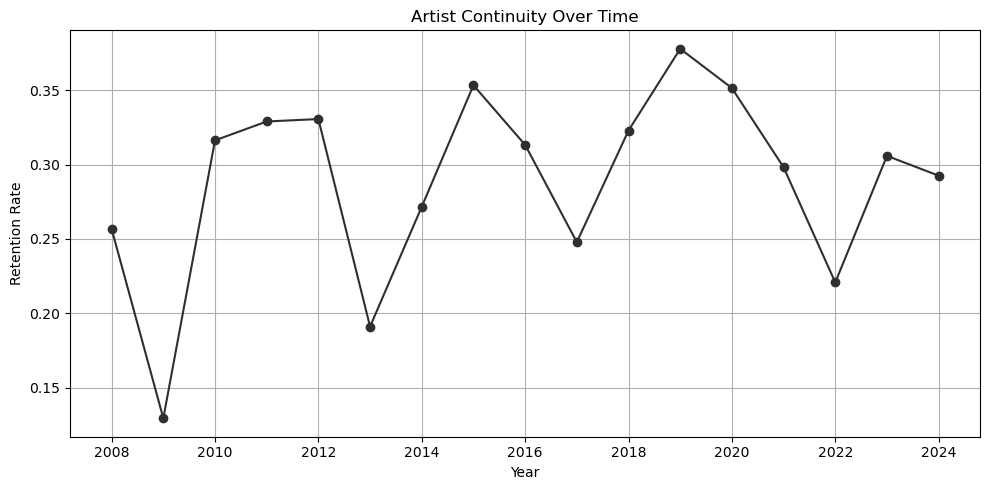

In [26]:
retention_series = pd.Series(retention)

plt.figure(figsize=(10, 5))
plt.plot(
    retention_series.index,
    retention_series.values,
    color=METRIC_COLOR,
    marker="o"
)

plt.title("Artist Continuity Over Time")
plt.ylabel("Retention Rate")
plt.xlabel("Year")
plt.grid(True)
plt.tight_layout()
plt.show()

## Conclusions

- Music discovery peaked around 2017.
- Listening shifted from rock toward electronic and ambient music.
- Artist concentration steadily decreased over time.
- Musical diversity remained high despite changing genre composition.
- Around one quarter to one third of the repertoire carried over between consecutive years.

The figures below are exported for use in the project README.